# Jawaban Tugas
## Bagian A (Eksplorasi Data Awal)
1. Informasi Dataset
Tampilkan:
• Jumlah data
• Jumlah variabel
• Tipe data tiap variabel
• Jumlah masing-masing spesies

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

In [39]:
i = load_iris()
data1 = pd.DataFrame(i.data, columns=i.feature_names)
data1['species'] = i.target
data1['species'] = data1['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})
data1.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [40]:
# Jumlah data dan variabel
print("Total data:", data1.shape[0])
print("Jumlah variabel:", data1.shape[1])
# Tipe data tiap variabel
print("\nTipe data:")
print(data1.dtypes)
# Jumlah masing-masing spesies
print("\nJumlah disetiap spesies:")
print(data1['species'].value_counts())

Total data: 150
Jumlah variabel: 5

Tipe data:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object

Jumlah disetiap spesies:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


2. Statistik Deskriptif
Hitung untuk semua variabel numerik:
• Mean
• Median
• Standar deviasi
• Minimum dan maksimum

In [41]:
# Statistik deskriptif manual
mean = data1.describe().loc['mean']
median = data1.median(numeric_only=True)
std = data1.std(numeric_only=True)
min = data1.min(numeric_only=True)
max = data1.max(numeric_only=True)
print("Mean:\n", mean)
print("\nMedian:\n", median)
print("\nStandar Deviasi:\n", std)
print("\nMinimum:\n", min)
print("\nMaximum:\n", max)

Mean:
 sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
Name: mean, dtype: float64

Median:
 sepal length (cm)    5.80
sepal width (cm)     3.00
petal length (cm)    4.35
petal width (cm)     1.30
dtype: float64

Standar Deviasi:
 sepal length (cm)    0.828066
sepal width (cm)     0.435866
petal length (cm)    1.765298
petal width (cm)     0.762238
dtype: float64

Minimum:
 sepal length (cm)    4.3
sepal width (cm)     2.0
petal length (cm)    1.0
petal width (cm)     0.1
dtype: float64

Maximum:
 sepal length (cm)    7.9
sepal width (cm)     4.4
petal length (cm)    6.9
petal width (cm)     2.5
dtype: float64


3. Visualisasi Distribusi
Buat:
a. Histogram untuk setiap variabel numerik
b. Boxplot untuk setiap variabel numerik
Jelaskan:
• Bentuk distribusi
• Sebaran data
• Apakah terdapat outlier
Jawaban:
Berdasarkan boxplot, sepal length memiliki distribusi relatif simetris tanpa outlier signifikan dan variasi sedang. Sepal width memiliki variasi kecil namun terdapat beberapa outlier. Petal length memiliki sebaran paling besar dengan variasi tinggi akibat perbedaan spesies, tetapi tidak menunjukkan outlier ekstrem. Petal width juga memiliki variasi cukup besar dan distribusi sedikit skewed tanpa outlier signifikan.

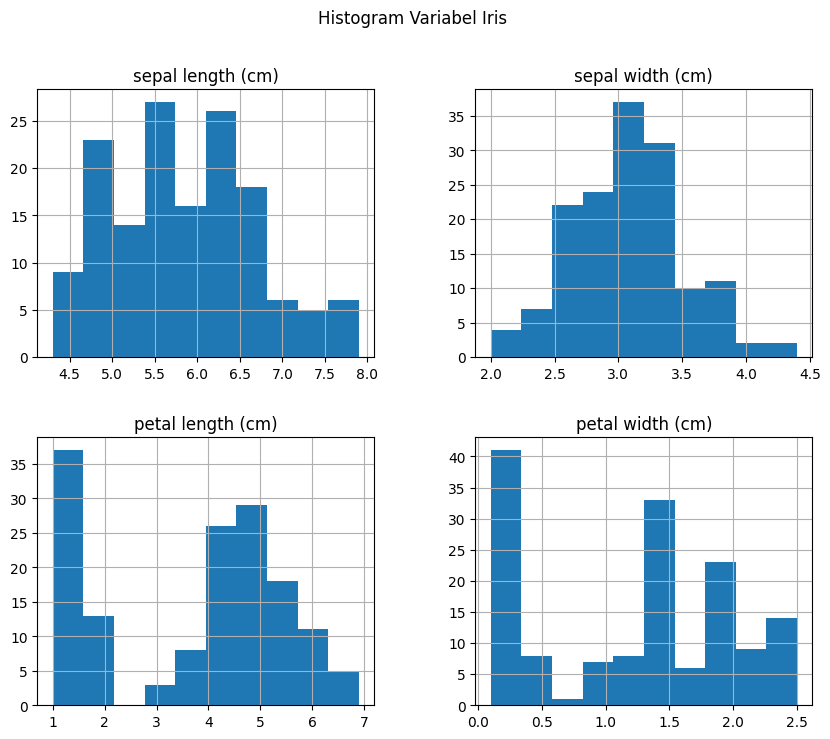

In [42]:
# Histogram untuk setiap variabel numerik
data1.hist(figsize=(10,8))
plt.suptitle("Histogram Variabel Iris")
plt.show()

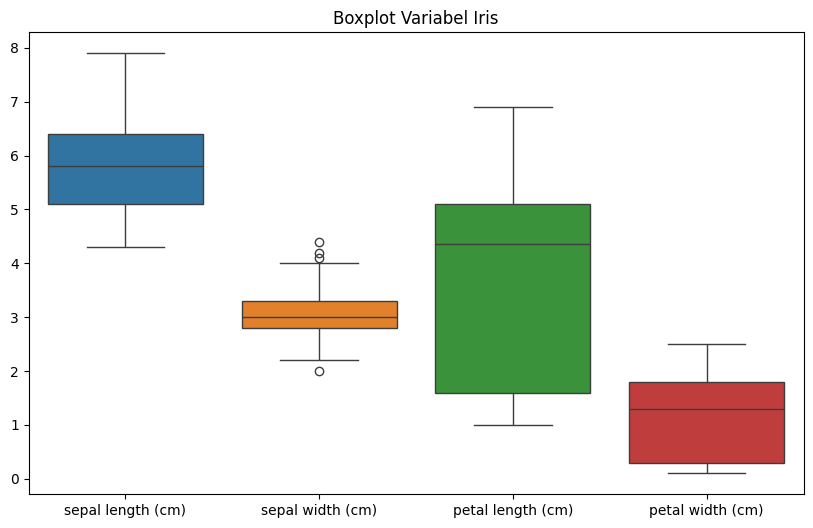

In [43]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data1.iloc[:,0:4])
plt.title("Boxplot Variabel Iris")
plt.show()

4. Visualisasi Berdasarkan Spesies
Buat salah satu:
• Boxplot per spesies
atau
• Violin plot per spesies
Jelaskan perbedaan antar spesies. (jawaban ada di bagian C)

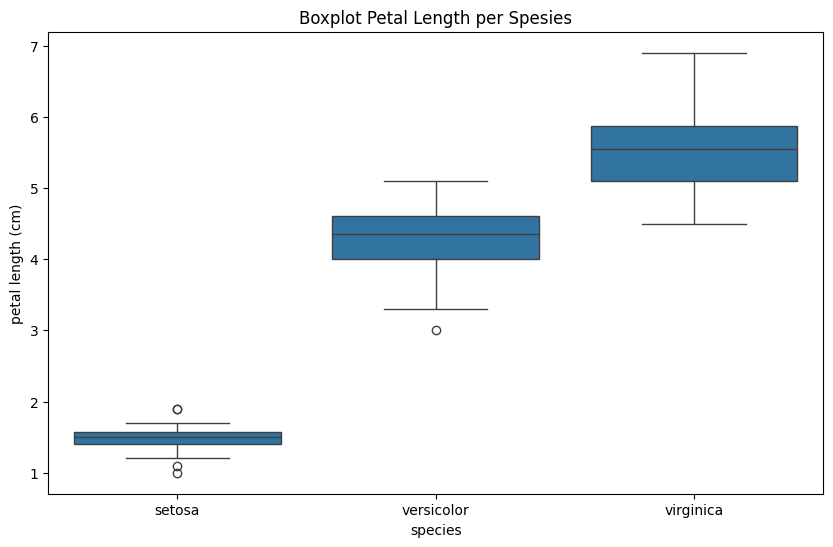

In [44]:
plt.figure(figsize=(10,6))
sns.boxplot(x='species', y='petal length (cm)', data=data1)
plt.title("Boxplot Petal Length per Spesies")
plt.show()

## Bagian B (Sampling (Bootstrap))
Pilih satu variabel numerik:
disarankan: petal length (cm)
1. Bootstrap Tunggal
Ambil satu sampel bootstrap:
• Ukuran sampel = jumlah data asli
• Sampling dengan pengembalian
Tampilkan:
• Mean bootstrap
• Median bootstrap
• Bandingkan dengan data asli

In [45]:
data2 = data1['petal length (cm)']
# Bootstrap tunggal
bootstrap_smpl = np.random.choice(data2, size=len(data2), replace=True)

# Hitung statistik
mean_bp = np.mean(bootstrap_smpl)
median_bp = np.median(bootstrap_smpl)

mean_real = np.mean(data2)
median_real = np.median(data2)

print("Mean Asli:", mean_real)
print("Mean Bootstrap:", mean_bp)
print("\nMedian Asli:", median_real)
print("Median Bootstrap:", median_bp)

Mean Asli: 3.7580000000000005
Mean Bootstrap: 3.971333333333334

Median Asli: 4.35
Median Bootstrap: 4.5


2. Bootstrap Berulang
Lakukan bootstrap:
• 100 kali
• 1000 kali
• 10000 kali
Hitung mean dari setiap sampel.

In [46]:
def bp_means(data2, n_bp):
    means = []
    for i in range(n_bp):
        sample = np.random.choice(data2, size=len(data2), replace=True)
        means.append(np.mean(sample))
    return means

means_100 = bp_means(data2, 100)
means_1000 = bp_means(data2, 1000)
means_10000 = bp_means(data2, 10000)

3. Visualisasi Hasil Bootstrap
Buat:
a. Histogram distribusi mean bootstrap
b. Boxplot mean bootstrap
Bandingkan hasil:
• Bootstrap 100
• Bootstrap 1000
• Bootstrap 10000

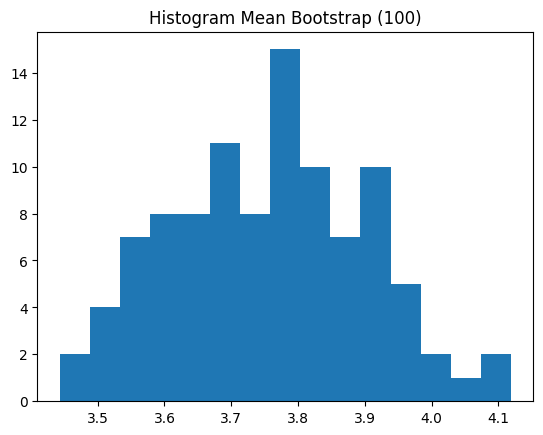

In [51]:
plt.hist(means_100, bins=15)
plt.title("Histogram Mean Bootstrap (100)")
plt.show()

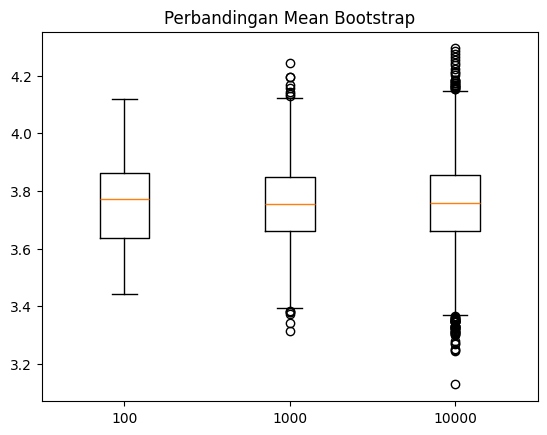

In [52]:
plt.boxplot([means_100, means_1000, means_10000])
plt.xticks([1,2,3], ['100', '1000', '10000'])
plt.title("Perbandingan Mean Bootstrap")
plt.show()

4. Interval Kepercayaan 95%
Hitung CI menggunakan persentil:
• 2.5%
• 97.5%
Bandingkan CI untuk:
• 100
• 1000
• 10000

In [55]:
def ci(data):
    lower = np.percentile(data, 2.5)
    upper = np.percentile(data, 97.5)
    return lower, upper

ci_100 = ci(means_100)
ci_1000 = ci(means_1000)
ci_10000 = ci(means_10000)

print("Interval Kepercayaan 100:", ci_100)
print("Interval Kepercayaan 1000:", ci_1000)
print("Interval Kepercayaan 10000:", ci_10000)

Interval Kepercayaan 100: (np.float64(3.49625), np.float64(4.033233333333333))
Interval Kepercayaan 1000: (np.float64(3.47725), np.float64(4.04605))
Interval Kepercayaan 10000: (np.float64(3.4726666666666666), np.float64(4.035999999999999))


## BAGIAN C (Perbandingan dan Analisis)
Jawab pertanyaan berikut:
1. Apakah mean bootstrap mendekati mean data asli?
2. Bagaimana perubahan distribusi saat jumlah bootstrap bertambah?
3. Mana yang lebih stabil: 100, 1000, atau 10000?
4. Apakah mean asli berada dalam interval kepercayaan?
5. Mengapa satu data bisa muncul berkali-kali pada bootstrap?
jawab:
1. Mean bootstrap mendekati mean asli karena bootstrap mensimulasikan distribusi sampling dari data asli
2. Apabila berdasarkan interpretasi pada distribusi ketika semakin besar jumlah bootstrap, distribusi semakin mendekati normal dan lebih stabil
3. Yang paling stabil yaitu 10000, karena hasil varians lebih kecil
4. Ya, mean asli berada dalam interval kepercayaan 95% dari hasil bootstrap. Hal ini dikarenakan distribusi bootstrap dibangun dari data asli sehingga estimasi mean bootstrap berada di sekitar mean asli. Semakin besar jumlah bootstrap (1000 atau 10000), interval menjadi lebih stabil dan semakin konsisten mencakup mean asli.
5. Satu data bisa muncul berkali-kali pada bootstrap karena menggunakan sampling dengan pengembalian (replace=True). Setelah suatu data yang akan diamati dipilih, data tersebut dikembalikan ke dalam populasi sehingga memiliki peluang yang sama untuk terpilih kembali.


## Bagian D (Kesimpulan)
Tuliskan:
• Insight utama dari EDA dataset Iris
• Karakteristik tiap spesies (berdasarkan visualisasi)
• Manfaat bootstrap dalam analisis data
• Jumlah bootstrap yang menurut Anda cukup
Jawab:
1. Berdasarkan EDA, dataset Iris memiliki distribusi yang seimbang antar spesies dan relatif bersih dari outlier ekstrem. Variabel petal length dan petal width menunjukkan perbedaan yang jelas antar spesies, terutama dalam memisahkan Setosa dari dua spesies lainnya. Karena ukuran Versicolor dan Virginica sedikit mirip, jadi tidak bisa melihat satu ukuran saja. Perlu melihat beberapa ukuran sekaligus supaya lebih akurat.
2. Berdasarkan visualisasi boxplot dan histogram, Setosa memiliki ukuran petal paling kecil dan terpisah jelas dari spesies lain. Versicolor memiliki ukuran sedang dan berada di antara Setosa dan Virginica. Virginica memiliki ukuran petal terbesar dengan sebaran yang lebih luas. Variabel petal length dan petal width paling efektif dalam membedakan ketiga spesies.
3. Bootstrap digunakan untuk mengestimasi ketidakpastian parameter, membentuk interval kepercayaan tanpa asumsi distribusi tertentu, serta mensimulasikan distribusi sampling dari data yang tersedia. Bootstrap sangat berguna ketika ukuran sampel terbatas dan membantu menghasilkan estimasi yang lebih stabil dan juga informatif.
4. Berdasarkan hasil percobaan 100, 1000, dan 10000 bootstrap, jumlah 1000 bootstrap sudah cukup menghasilkan distribusi mean yang stabil dan interval kepercayaan yang konsisten